# Getting Started with Zipminator

This notebook demonstrates the core Zipminator workflow: generating Kyber768 keypairs,
encrypting and decrypting messages, and applying DataFrame anonymization.

**Prerequisites**: `micromamba activate zip-pqc && uv pip install -e '.[jupyter,data]'`

Optionally run `maturin develop` to use the faster Rust backend. Without it, the pure-Python
fallback (`kyber-py`) is used automatically.

In [1]:
# Generate a Kyber768 keypair
from zipminator import keypair, encapsulate, decapsulate, RUST_AVAILABLE

# Helper: Rust FFI returns custom types with .to_bytes(); Python returns raw bytes
def to_bytes(obj):
    return obj.to_bytes() if hasattr(obj, 'to_bytes') else obj

pk, sk = keypair()

print(f"Backend:          {'Rust (native)' if RUST_AVAILABLE else 'Python (kyber-py)'}")
print(f"Public key size:  {len(to_bytes(pk))} bytes")
print(f"Secret key size:  {len(to_bytes(sk))} bytes")
print(f"Public key (hex): {to_bytes(pk)[:16].hex()}...")

Backend:          Rust (native)
Public key size:  1184 bytes
Secret key size:  2400 bytes
Public key (hex): ec6c7646228260a267a298bb7bd4afe3...


In [2]:
# Encrypt and decrypt a message using KEM + AES-256-GCM
from hashlib import sha3_256
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
import os

# KEM encapsulation: sender gets ciphertext + shared secret
ct, shared_secret_sender = encapsulate(pk)
print(f"Ciphertext size:    {len(to_bytes(ct))} bytes")
print(f"Shared secret (tx): {shared_secret_sender.hex()[:32]}...")

# KEM decapsulation: receiver recovers the same shared secret
shared_secret_receiver = decapsulate(ct, sk)
print(f"Shared secret (rx): {shared_secret_receiver.hex()[:32]}...")
assert shared_secret_sender == shared_secret_receiver, "Shared secrets must match!"
print("Shared secrets match.")

# Derive AES-256 key from shared secret
aes_key = sha3_256(shared_secret_sender).digest()

# Encrypt a message
aesgcm = AESGCM(aes_key)
nonce = os.urandom(12)
message = b"Hello from the post-quantum world!"
ciphertext = aesgcm.encrypt(nonce, message, None)
print(f"\nPlaintext:  {message.decode()}")
print(f"Ciphertext: {ciphertext[:24].hex()}... ({len(ciphertext)} bytes)")

# Decrypt
plaintext = aesgcm.decrypt(nonce, ciphertext, None)
print(f"Decrypted:  {plaintext.decode()}")

Ciphertext size:    1088 bytes
Shared secret (tx): 494e5ca845dc9bca897c33dbe9dc43d5...
Shared secret (rx): 494e5ca845dc9bca897c33dbe9dc43d5...
Shared secrets match.

Plaintext:  Hello from the post-quantum world!
Ciphertext: 27ef7ae73f4f4672d312f7c8acc0e537ed90b063cad364ee... (50 bytes)
Decrypted:  Hello from the post-quantum world!


In [3]:
# IPython magics: interactive PQC in one line
%load_ext zipminator.jupyter
%zipminator_info

Version,0.5.0b1
Backend,RUST (native)
Algorithm,ML-KEM-768 (FIPS 203)
PK / SK / CT,1184 / 2400 / 1088 bytes
Shared secret,32 bytes
Entropy pool,"33,792 bytes"


In [4]:
# Magic round-trip
%keygen
%encrypt pk
%decrypt ct sk
print(f"Shared secrets match: {shared_secret == recovered}")

Public key,1184 bytes
Secret key,2400 bytes
PK preview,32 69 4f 85 63 7a de 64 54 f4 27 55 df f9 a7 23 f3 78 6f 84 2a 65 15 32 1c b8 37 7b 08 b9 2a 28 ...
Elapsed,0.07 ms
Entropy,SYSTEM RNG


Ciphertext,1088 bytes
Shared secret,32 bytes
CT preview,50 1b 14 09 8a b7 8c 70 dc 07 b2 66 d5 6e 94 2d cd 7d c9 08 29 0d e1 50 da 8b 22 2e 5f 4a c5 00 ...
SS preview,62 dd f1 ef d7 e9 00 01 8e 11 39 83 7a a0 78 8c cf fe 5e 94 fc 02 a9 b2 98 76 e5 07 7e 0e f6 59
Elapsed,0.11 ms


Shared secret,32 bytes
SS preview,62 dd f1 ef d7 e9 00 01 8e 11 39 83 7a a0 78 8c cf fe 5e 94 fc 02 a9 b2 98 76 e5 07 7e 0e f6 59
Elapsed,0.12 ms


Shared secrets match: True


In [5]:
# DataFrame anonymization with PII scanning
import pandas as pd
from zipminator.anonymizer import AdvancedAnonymizer

anonymizer = AdvancedAnonymizer()

df = pd.DataFrame({
    "name": ["Alice Johnson", "Bob Smith", "Carol Williams"],
    "email": ["alice@example.com", "bob@corp.net", "carol@hospital.org"],
    "phone": ["555-123-4567", "555-987-6543", "555-246-8135"],
    "salary": [85000, 92000, 78000],
})

print("Original DataFrame:")
print(df.to_string(index=False))
print()

# Anonymize: level_map assigns anonymization level per column
level_map = {col: 1 for col in df.columns}
result = anonymizer.process(df, level_map)
print("Level 1 Anonymized (Minimal Masking):")
print(result.to_string(index=False))

Original DataFrame:
          name              email        phone  salary
 Alice Johnson  alice@example.com 555-123-4567   85000
     Bob Smith       bob@corp.net 555-987-6543   92000
Carol Williams carol@hospital.org 555-246-8135   78000

Level 1 Anonymized (Minimal Masking):
          name             email        phone salary
 *********nson  a***@example.com ********4567  *5000
     *****mith     b***@corp.net ********6543  *2000
**********iams c***@hospital.org ********8135  *8000


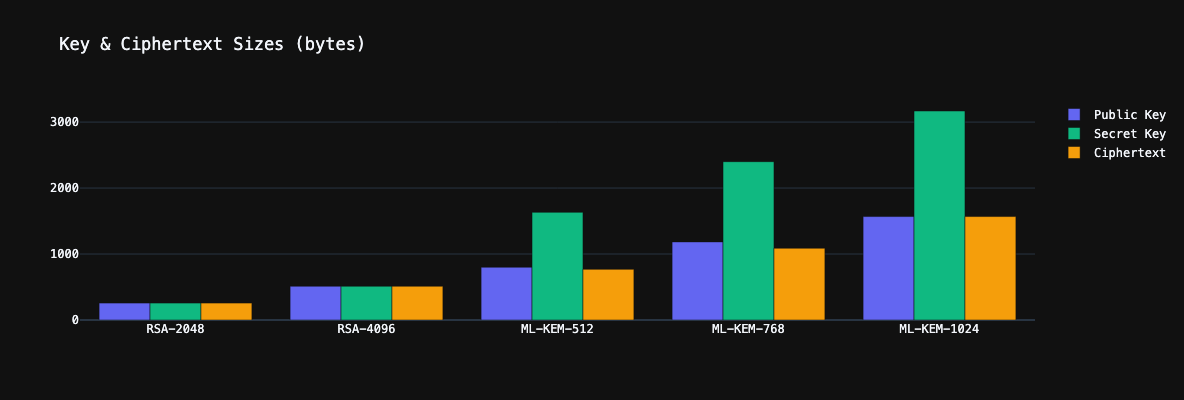

In [6]:
# Interactive widgets
from zipminator.jupyter.widgets import key_size_comparison, entropy_monitor
key_size_comparison()